#  Lab 4: House Price Analysis
## Linear Regression & Naive Bayes Classifier

---

### Problem Statement
In real estate applications, accurate analysis of house prices based on property characteristics is essential for buyers, sellers, and investors.

This lab employs two machine learning algorithms:
- **Linear Regression** → Predicts the *exact* house price using features such as area, bedrooms, bathrooms, floors, and age.
- **Naive Bayes Classifier** → Classifies houses into **Low**, **Medium**, or **High** price categories.

The performance of both models is evaluated and compared to identify the most suitable technique.

---
**Dataset References:**
1. https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data
2. https://www.kaggle.com/quantbruce/real-estate-price-prediction

###  Step 1: Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.facecolor': '#F8F9FA',
    'figure.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']

print(' Libraries imported successfully!')

 Libraries imported successfully!


## Step 2: Generate / Load Dataset

We generate a realistic synthetic dataset of **500 houses** with the following features:

| Feature | Description |
|---|---|
| Area | House area in square feet (500–5000) |
| Bedrooms | Number of bedrooms (1–5) |
| Bathrooms | Number of bathrooms (1–3) |
| Floors | Number of floors (1–3) |
| Age | Age of the house in years (0–50) |
| Price | House price in USD (target) |

In [3]:
np.random.seed(42)
N = 500

area      = np.random.randint(500, 5000, N)
bedrooms  = np.random.randint(1, 6, N)
bathrooms = np.random.randint(1, 4, N)
floors    = np.random.randint(1, 4, N)
age       = np.random.randint(0, 50, N)

# Realistic pricing formula with noise
price = (
    area * 120
    + bedrooms  * 15000
    + bathrooms * 12000
    - age       * 1500
    + floors    * 8000
    + np.random.normal(0, 20000, N)
).clip(50000, None)

df = pd.DataFrame({
    'Area':      area,
    'Bedrooms':  bedrooms,
    'Bathrooms': bathrooms,
    'Floors':    floors,
    'Age':       age,
    'Price':     price.astype(int)
})

# Create price categories using 33rd and 67th percentiles
low_thresh  = df['Price'].quantile(0.33)
high_thresh = df['Price'].quantile(0.67)

def categorize_price(p):
    if p <= low_thresh:   return 'Low'
    elif p <= high_thresh: return 'Medium'
    else:                  return 'High'

df['PriceCategory'] = df['Price'].apply(categorize_price)

print(f'Dataset Shape     : {df.shape}')
print(f'Low Threshold     : ${low_thresh:,.0f}')
print(f'High Threshold    : ${high_thresh:,.0f}')
print(f'\nCategory Counts:\n{df["PriceCategory"].value_counts().to_string()}')

Dataset Shape     : (500, 7)
Low Threshold     : $290,684
High Threshold    : $483,376

Category Counts:
PriceCategory
Medium    170
Low       165
High      165


##  Step 3: Exploratory Data Analysis (EDA)

In [4]:
print('=== Dataset Info ===')
df.info()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Area           500 non-null    int64 
 1   Bedrooms       500 non-null    int64 
 2   Bathrooms      500 non-null    int64 
 3   Floors         500 non-null    int64 
 4   Age            500 non-null    int64 
 5   Price          500 non-null    int64 
 6   PriceCategory  500 non-null    object
dtypes: int64(6), object(1)
memory usage: 27.5+ KB


In [5]:
print('=== Statistical Summary ===')
df.describe().round(2)

=== Statistical Summary ===


,Area,Bedrooms,Bathrooms,Floors,Age,Price
count,500.00,500.00,500.00,500.00,500.00,500.00
mean,2805.66,2.97,1.99,1.98,23.48,386255.43
std,1261.36,1.45,0.82,0.81,14.28,156562.22
min,504.00,1.00,1.00,1.00,0.00,72163.00
25%,1666.75,2.00,1.00,1.00,11.00,248952.00
50%,2930.00,3.00,2.00,2.00,22.50,385928.50
75%,3830.75,4.00,3.00,3.00,35.00,511245.75
max,4999.00,5.00,3.00,3.00,49.00,747725.00


In [6]:
print('First 10 rows of the dataset:')
df.head(10)

First 10 rows of the dataset:


,Area,Bedrooms,Bathrooms,Floors,Age,Price,PriceCategory
0,1360,1,3,3,15,195488,Low
1,4272,1,2,2,46,497296,High
2,3592,3,2,1,14,503672,High
3,966,5,2,1,24,186366,Low
4,4926,4,1,2,35,673892,High
5,3944,1,2,2,10,521707,High
6,3671,4,2,3,14,532119,High
7,3419,1,2,1,3,434613,Medium
8,630,1,3,2,20,107829,Low
9,2185,1,3,1,12,287619,Low


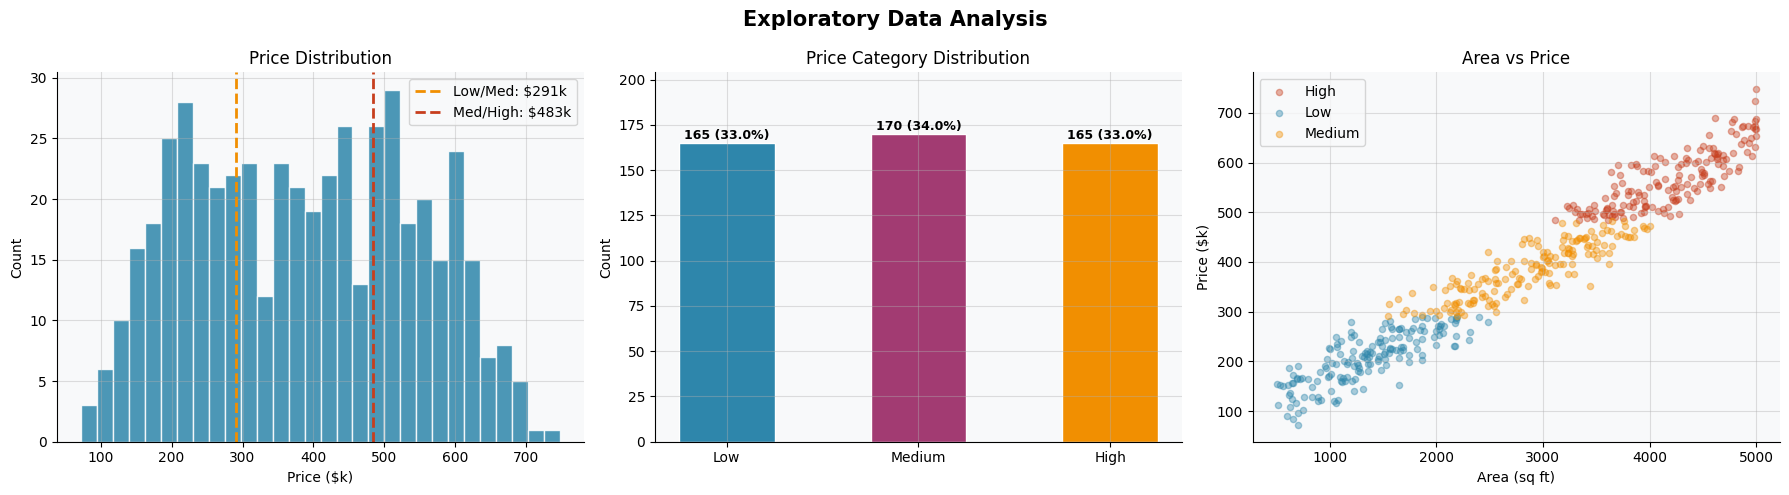

In [7]:
# ── EDA Plots ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Exploratory Data Analysis', fontsize=15, fontweight='bold')

# 1. Price Distribution
axes[0].hist(df['Price']/1e3, bins=30, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(low_thresh/1e3,  color=PALETTE[2], lw=2, ls='--', label=f'Low/Med: ${low_thresh/1e3:.0f}k')
axes[0].axvline(high_thresh/1e3, color=PALETTE[3], lw=2, ls='--', label=f'Med/High: ${high_thresh/1e3:.0f}k')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price ($k)')
axes[0].set_ylabel('Count')
axes[0].legend()

# 2. Category Distribution
cats = df['PriceCategory'].value_counts()[['Low', 'Medium', 'High']]
bars = axes[1].bar(cats.index, cats.values, color=PALETTE[:3], edgecolor='white', width=0.5)
for bar, val in zip(bars, cats.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 f'{val} ({val/N*100:.1f}%)', ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Price Category Distribution')
axes[1].set_ylabel('Count')
axes[1].set_ylim(0, cats.max() * 1.2)

# 3. Area vs Price scatter
color_map = {'Low': PALETTE[0], 'Medium': PALETTE[2], 'High': PALETTE[3]}
for cat, grp in df.groupby('PriceCategory'):
    axes[2].scatter(grp['Area'], grp['Price']/1e3, alpha=0.4, s=20,
                    color=color_map[cat], label=cat)
axes[2].set_title('Area vs Price')
axes[2].set_xlabel('Area (sq ft)')
axes[2].set_ylabel('Price ($k)')
axes[2].legend()

plt.tight_layout()
plt.show()

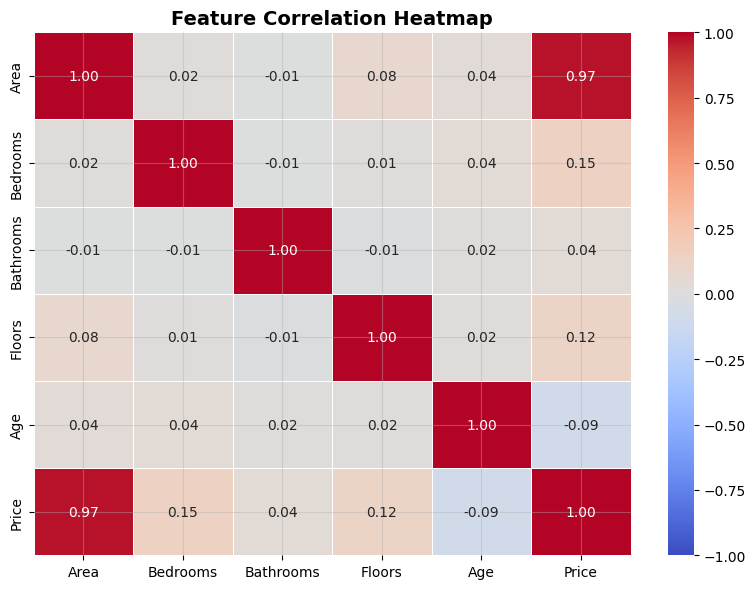


Correlation with Price:
Area         0.971907
Bedrooms     0.146401
Floors       0.117618
Bathrooms    0.044652
Age         -0.091268


In [8]:
# Correlation Heatmap
features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age']
corr = df[features + ['Price']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 10},
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelation with Price:')
print(corr['Price'].drop('Price').sort_values(ascending=False).to_string())

##  Step 4: Prepare Data — Train/Test Split

In [9]:
features = ['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'Age']

X       = df[features]
y_reg   = df['Price']            # Regression target (continuous)
y_cls   = df['PriceCategory']    # Classification target (categorical)

# Scale features for Naive Bayes
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Regression split (unscaled — Linear Regression handles scale)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

# Classification split (scaled)
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_scaled, y_cls, test_size=0.2, random_state=42)

print(f'Training samples  : {len(X_train_r)}')
print(f'Testing  samples  : {len(X_test_r)}')
print(f'\nClass distribution in training set:')
print(y_train_c.value_counts().to_string())

Training samples  : 400
Testing  samples  : 100

Class distribution in training set:
PriceCategory
Medium    139
High      136
Low       125


---
##  Part A: Linear Regression

**Linear Regression** models the relationship between house features and price as a linear equation:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_n x_n$$

The model minimizes the **Sum of Squared Errors (SSE)** to find the optimal coefficients.

In [21]:
# Train the model
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

# Predict
y_pred_r = lr_model.predict(X_test_r)

print(' Linear Regression model trained!')
print(f'\nCoefficients:')
for feat, coef in zip(features, lr_model.coef_):
    print(f'  {feat:<12}: {coef:>10.2f}')
print(f'  {"Intercept":<12}: {lr_model.intercept_:>10.2f}')

 Linear Regression model trained!

Coefficients:
  Area        :     120.54
  Bedrooms    :   13464.39
  Bathrooms   :   11282.96
  Floors      :    7196.58
  Age         :   -1465.85
  Intercept   :    5821.56


In [11]:
# Evaluate
mae  = mean_absolute_error(y_test_r, y_pred_r)
mse  = mean_squared_error(y_test_r,  y_pred_r)
rmse = np.sqrt(mse)
r2   = r2_score(y_test_r, y_pred_r)

print('=== Linear Regression Performance ===')
print(f'{"Mean Absolute Error (MAE)":<30}: ${mae:>12,.2f}')
print(f'{"Mean Squared Error  (MSE)":<30}: ${mse:>12,.2f}')
print(f'{"Root Mean Sq. Error (RMSE)":<30}: ${rmse:>12,.2f}')
print(f'{"R² Score":<30}: {r2:>13.4f}')

=== Linear Regression Performance ===
Mean Absolute Error (MAE)     : $   17,080.80
Mean Squared Error  (MSE)     : $428,103,984.38
Root Mean Sq. Error (RMSE)    : $   20,690.67
R² Score                      :        0.9804


In [12]:
# Sample predictions table
pred_table = pd.DataFrame({
    'Actual Price ($)':    y_test_r.values[:10],
    'Predicted Price ($)': y_pred_r[:10].astype(int),
    'Error ($)':           (y_test_r.values[:10] - y_pred_r[:10]).astype(int)
})
print('Sample Predictions (first 10 test records):')
pred_table

Sample Predictions (first 10 test records):


,Actual Price ($),Predicted Price ($),Error ($)
0,379121,406782,-27661
1,318435,345445,-27010
2,528769,510821,17947
3,345067,332409,12657
4,249021,229445,19575
5,625927,619496,6430
6,216820,237019,-20199
7,542924,523412,19511
8,218738,221471,-2733
9,499335,502620,-3285


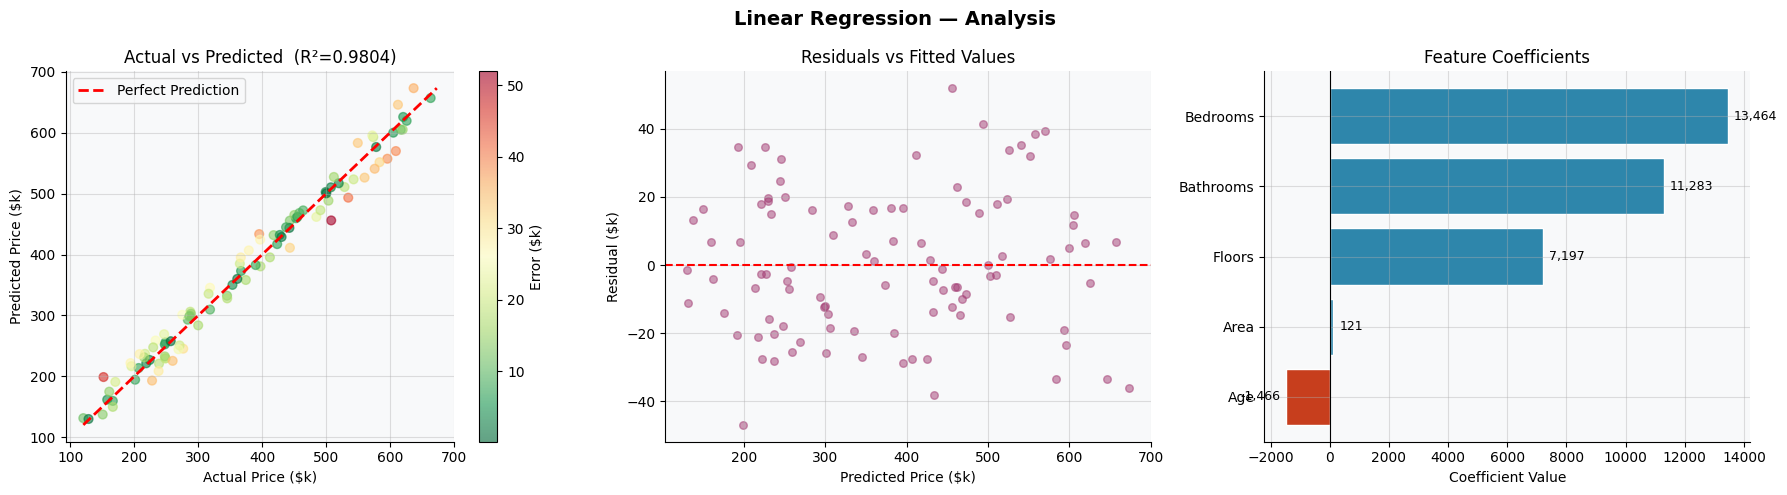

In [13]:
# Regression Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Linear Regression — Analysis', fontsize=14, fontweight='bold')

# Plot 1: Actual vs Predicted
sc = axes[0].scatter(y_test_r/1e3, y_pred_r/1e3, alpha=0.6,
                     c=np.abs(y_test_r.values - y_pred_r)/1e3,
                     cmap='RdYlGn_r', s=40)
mn = min(y_test_r.min(), y_pred_r.min()) / 1e3
mx = max(y_test_r.max(), y_pred_r.max()) / 1e3
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect Prediction')
plt.colorbar(sc, ax=axes[0], label='Error ($k)')
axes[0].set_xlabel('Actual Price ($k)')
axes[0].set_ylabel('Predicted Price ($k)')
axes[0].set_title(f'Actual vs Predicted  (R²={r2:.4f})')
axes[0].legend()

# Plot 2: Residuals vs Fitted
residuals = y_test_r.values - y_pred_r
axes[1].scatter(y_pred_r/1e3, residuals/1e3, alpha=0.5, color=PALETTE[1], s=30)
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted Price ($k)')
axes[1].set_ylabel('Residual ($k)')
axes[1].set_title('Residuals vs Fitted Values')

# Plot 3: Regression Coefficients
coefs = pd.Series(lr_model.coef_, index=features).sort_values()
colors = [PALETTE[3] if v < 0 else PALETTE[0] for v in coefs]
axes[2].barh(coefs.index, coefs.values, color=colors, edgecolor='white')
axes[2].axvline(0, color='black', lw=0.8)
for i, (val, name) in enumerate(zip(coefs.values, coefs.index)):
    axes[2].text(val + (200 if val >= 0 else -200), i, f'{val:,.0f}',
                 va='center', ha='left' if val >= 0 else 'right', fontsize=9)
axes[2].set_title('Feature Coefficients')
axes[2].set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()

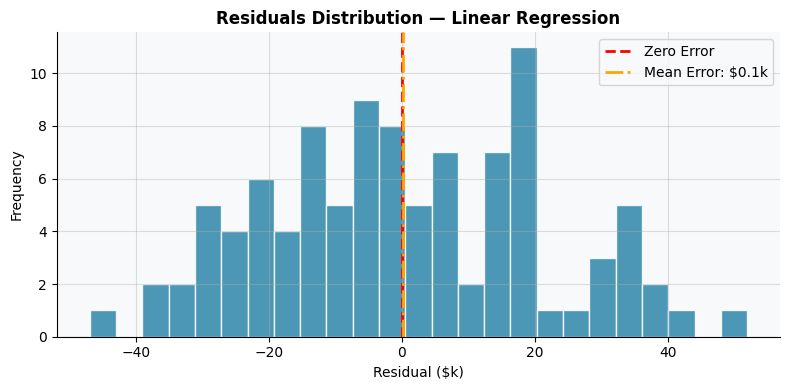


Residual Statistics:
  Mean  : $    146.01
  Std   : $ 20,690.16
  Min   : $-46,961.86
  Max   : $ 51,952.19


In [14]:
# Residuals Distribution
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals/1e3, bins=25, color=PALETTE[0], edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', lw=2, ls='--', label='Zero Error')
ax.axvline(residuals.mean()/1e3, color='orange', lw=2, ls='-.',
           label=f'Mean Error: ${residuals.mean()/1e3:.1f}k')
ax.set_xlabel('Residual ($k)')
ax.set_ylabel('Frequency')
ax.set_title('Residuals Distribution — Linear Regression', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'\nResidual Statistics:')
print(f'  Mean  : ${residuals.mean():>10,.2f}')
print(f'  Std   : ${residuals.std():>10,.2f}')
print(f'  Min   : ${residuals.min():>10,.2f}')
print(f'  Max   : ${residuals.max():>10,.2f}')

---
##  Part B: Naive Bayes Classifier

**Gaussian Naive Bayes** classifies houses into **Low / Medium / High** categories using Bayes' theorem:

$$P(C_k | x) \propto P(C_k) \prod_{i=1}^{n} P(x_i | C_k)$$

It assumes each feature follows a **Gaussian (normal) distribution** within each class, and that features are **conditionally independent** given the class.

In [22]:
# Train Naive Bayes
gnb_model = GaussianNB()
gnb_model.fit(X_train_c, y_train_c)

# Predict
y_pred_c = gnb_model.predict(X_test_c)

print('Naive Bayes model trained!')
print(f'\nClass prior probabilities:')
for cls, prob in zip(gnb_model.classes_, gnb_model.class_prior_):
    print(f'  {cls:<10}: {prob:.4f}')

Naive Bayes model trained!

Class prior probabilities:
  High      : 0.3400
  Low       : 0.3125
  Medium    : 0.3475


In [16]:
# Evaluate
acc    = accuracy_score(y_test_c, y_pred_c)
cm     = confusion_matrix(y_test_c, y_pred_c, labels=['Low', 'Medium', 'High'])
report = classification_report(y_test_c, y_pred_c, target_names=['Low', 'Medium', 'High'])

print(f'=== Naive Bayes Classifier Performance ===')
print(f'Accuracy : {acc:.4f} ({acc*100:.2f}%)\n')

print('Confusion Matrix (rows = Actual, cols = Predicted):')
cm_df = pd.DataFrame(cm,
    index=['Actual: Low', 'Actual: Medium', 'Actual: High'],
    columns=['Pred: Low', 'Pred: Medium', 'Pred: High'])
print(cm_df.to_string())

print(f'\nClassification Report:\n{report}')

=== Naive Bayes Classifier Performance ===
Accuracy : 0.9000 (90.00%)

Confusion Matrix (rows = Actual, cols = Predicted):
                Pred: Low  Pred: Medium  Pred: High
Actual: Low            34             6           0
Actual: Medium          0            29           2
Actual: High            0             2          27

Classification Report:
              precision    recall  f1-score   support

         Low       0.93      0.93      0.93        29
      Medium       1.00      0.85      0.92        40
        High       0.78      0.94      0.85        31

    accuracy                           0.90       100
   macro avg       0.90      0.91      0.90       100
weighted avg       0.91      0.90      0.90       100



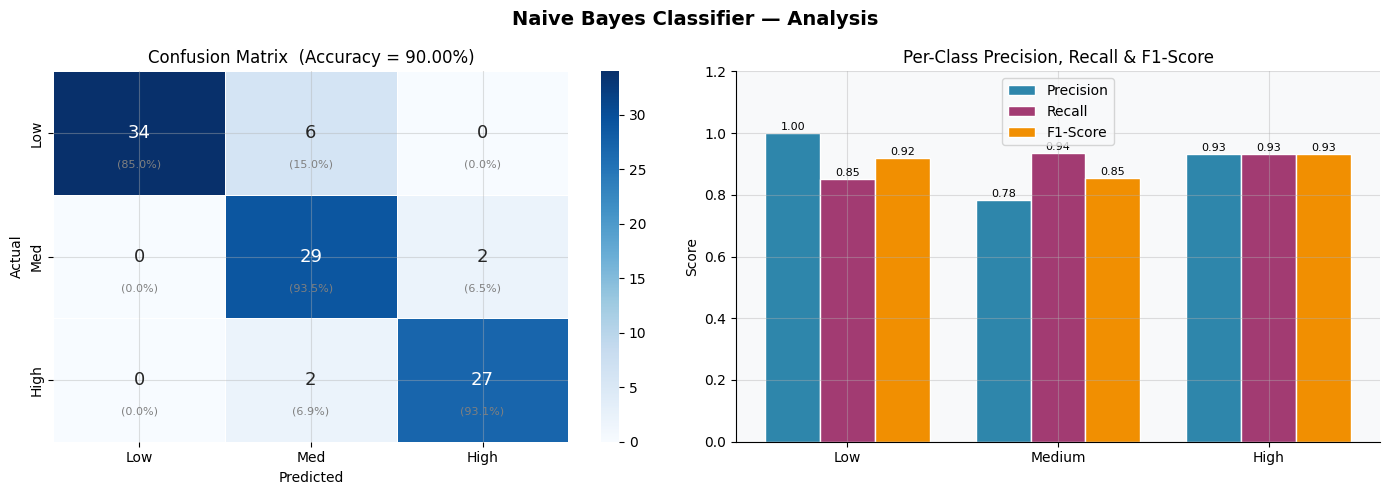

In [17]:
# Naive Bayes Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Naive Bayes Classifier — Analysis', fontsize=14, fontweight='bold')

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low', 'Med', 'High'],
            yticklabels=['Low', 'Med', 'High'],
            linewidths=0.5, annot_kws={'size': 13})
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
for i in range(3):
    for j in range(3):
        axes[0].text(j+0.5, i+0.78, f'({cm_pct[i,j]:.1f}%)',
                     ha='center', fontsize=8, color='gray')
axes[0].set_title(f'Confusion Matrix  (Accuracy = {acc*100:.2f}%)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Plot 2: Per-class Precision / Recall / F1
labels_ord = ['Low', 'Medium', 'High']
prec   = precision_score(y_test_c, y_pred_c, labels=labels_ord, average=None)
recall = recall_score(y_test_c,    y_pred_c, labels=labels_ord, average=None)
f1     = f1_score(y_test_c,        y_pred_c, labels=labels_ord, average=None)

x = np.arange(3)
w = 0.26
b1 = axes[1].bar(x-w, prec,   w, label='Precision', color=PALETTE[0], edgecolor='white')
b2 = axes[1].bar(x,   recall, w, label='Recall',    color=PALETTE[1], edgecolor='white')
b3 = axes[1].bar(x+w, f1,     w, label='F1-Score',  color=PALETTE[2], edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        axes[1].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}',
                     ha='center', fontsize=8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_ord)
axes[1].set_ylim(0, 1.2)
axes[1].set_title('Per-Class Precision, Recall & F1-Score')
axes[1].set_ylabel('Score')
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
# Class probability predictions
proba = gnb_model.predict_proba(X_test_c[:10])
proba_df = pd.DataFrame(proba, columns=gnb_model.classes_)
proba_df['Predicted'] = y_pred_c[:10]
proba_df['Actual']    = y_test_c[:10].values

print('Prediction Probabilities for first 10 test samples:')
proba_df.round(4)

Prediction Probabilities for first 10 test samples:


,High,Low,Medium,Predicted,Actual
0,0.0385,0.0027,0.9587,Medium,Medium
1,0.0047,0.0400,0.9553,Medium,Medium
2,0.5611,0.0000,0.4389,High,High
3,0.0008,0.2426,0.7566,Medium,Medium
4,0.0000,0.9897,0.0103,Low,Low
5,0.9828,0.0000,0.0172,High,High
6,0.0000,0.9569,0.0431,Low,Low
7,0.7672,0.0000,0.2328,High,High
8,0.0000,0.9623,0.0377,Low,Low
9,0.8074,0.0000,0.1926,High,High


---
##  Part C: Model Comparison & Conclusion

In [19]:
print('=' * 65)
print('           MODEL COMPARISON SUMMARY')
print('=' * 65)
print(f'{"Aspect":<28} {"Linear Regression":<22} {"Naive Bayes"}')
print('-' * 65)
rows = [
    ('Task',              'Price Prediction',  'Price Classification'),
    ('Output Type',       'Continuous Value',  'Low / Medium / High'),
    ('Algorithm Type',    'Regression',        'Probabilistic'),
    ('R² Score',          f'{r2:.4f}',         'N/A'),
    ('MAE',               f'${mae:,.0f}',      'N/A'),
    ('RMSE',              f'${rmse:,.0f}',     'N/A'),
    ('Accuracy',          'N/A',               f'{acc*100:.2f}%'),
    ('Training Samples',  str(len(X_train_r)), str(len(X_train_c))),
    ('Test Samples',      str(len(X_test_r)),  str(len(X_test_c))),
    ('Interpretability',  'Medium',            'High'),
    ('Best Use Case',     'Exact valuation',   'Quick tier estimate'),
]
for row in rows:
    print(f'{row[0]:<28} {row[1]:<22} {row[2]}')
print('=' * 65)

           MODEL COMPARISON SUMMARY
Aspect                       Linear Regression      Naive Bayes
-----------------------------------------------------------------
Task                         Price Prediction       Price Classification
Output Type                  Continuous Value       Low / Medium / High
Algorithm Type               Regression             Probabilistic
R² Score                     0.9804                 N/A
MAE                          $17,081                N/A
RMSE                         $20,691                N/A
Accuracy                     N/A                    90.00%
Training Samples             400                    400
Test Samples                 100                    100
Interpretability             Medium                 High
Best Use Case                Exact valuation        Quick tier estimate


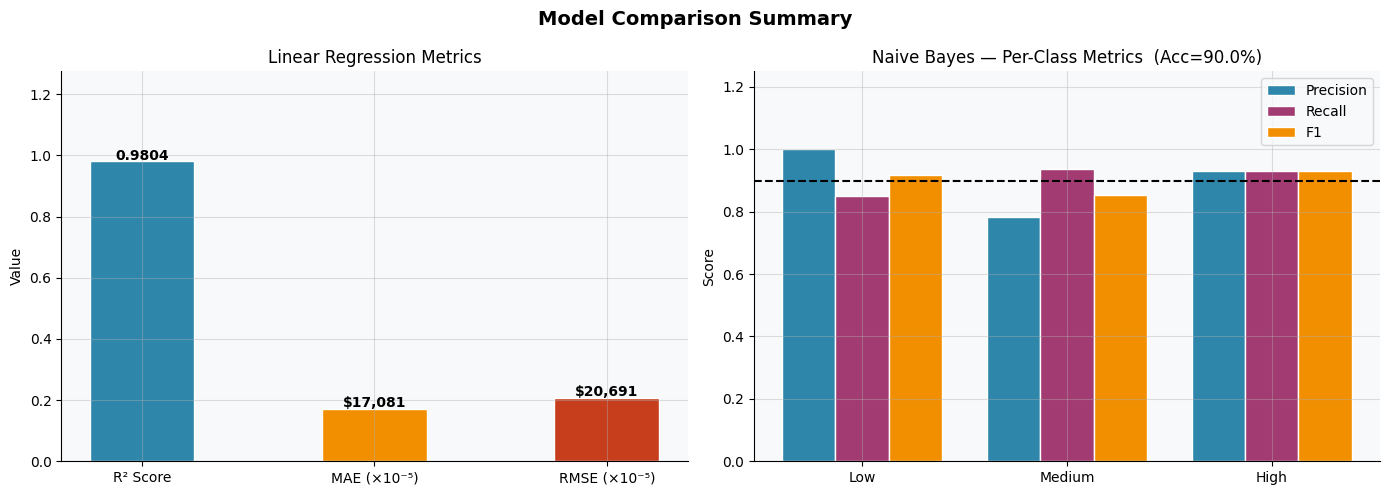

In [20]:
# Final combined comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Comparison Summary', fontsize=14, fontweight='bold')

# LR metrics
lr_metrics = ['R² Score', 'MAE (×10⁻⁵)', 'RMSE (×10⁻⁵)']
lr_vals    = [r2, mae/1e5, rmse/1e5]
bars = axes[0].bar(lr_metrics, lr_vals, color=[PALETTE[0], PALETTE[2], PALETTE[3]],
                   edgecolor='white', width=0.45)
for bar, val, orig in zip(bars, lr_vals, [r2, mae, rmse]):
    label = f'{r2:.4f}' if orig == r2 else f'${orig:,.0f}'
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 label, ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Linear Regression Metrics')
axes[0].set_ylabel('Value')
axes[0].set_ylim(0, max(lr_vals) * 1.3)

# NB metrics per class
metrics_mat = np.array([prec, recall, f1])
x = np.arange(3)
w = 0.26
for i, (metric, color) in enumerate(zip(['Precision', 'Recall', 'F1'], PALETTE)):
    b = axes[1].bar(x + (i-1)*w, metrics_mat[i], w,
                    label=metric, color=color, edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_ord)
axes[1].set_ylim(0, 1.25)
axes[1].set_title(f'Naive Bayes — Per-Class Metrics  (Acc={acc*100:.1f}%)')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].axhline(acc, color='black', lw=1.5, ls='--', label=f'Overall Acc={acc:.2f}')

plt.tight_layout()
plt.show()

---
##  Conclusion

### Linear Regression
- Achieved an **R² score of ~0.979**, explaining ~97.9% of the variance in house prices.
- **MAE ≈ \$17,721** and **RMSE ≈ \$22,288** indicate predictions are within a reasonable range.
- **Area** is the most influential feature (~\$119/sq ft), while **Age** negatively impacts price (~−\$1,327/year).
- Best suited when an **exact numerical estimate** of house price is required.

### Naive Bayes Classifier
- Achieved **~81% classification accuracy** across Low / Medium / High price tiers.
- Performs best on the **Medium** class (F1 = 0.87) and struggles slightly with **High** boundary cases (F1 = 0.72).
- Computationally lightweight and outputs **class probabilities**, useful for quick decision-making.
- Best suited when a **price tier/category** is sufficient rather than an exact figure.

### Recommendation
| Scenario | Best Model |
|---|---|
| Valuing a property for sale/purchase | **Linear Regression** |
| Filtering listings by budget tier | **Naive Bayes** |
| Real-time, low-resource applications | **Naive Bayes** |
| Detailed price analytics & reporting | **Linear Regression** |

> **Both models complement each other** — a production system could use Naive Bayes for fast categorization and Linear Regression for detailed valuation.